<a href="https://colab.research.google.com/github/shreyansh-dev0/google-colab/blob/main/Lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2. Divide and Conquer (Sorting)

- **Created by Dr. Ajay

Write a python program to perform **Countingsort**.
* Statement:  Given a disordered list of repeated integers, rearrange the integers in natural order.
 Sample Input: [4,3,2,1,4,3,2,4,3,4]
 Sample Output: [1,2,2,3,3,3,4,4,4,4]

Time Complexity of Solution: Best Case O(n+k); Average Case O(n+k); Worst Case O(n+k), where n is the size of the input array and k means the values range from 0 to k.
- Approach:
Counting sort, like radix sort and bucket sort, is an integer based algorithm (i.e. the values of the input array are assumed to be integers). Hence counting sort is among the fastest sorting algorithms around, in theory. The  particular distinction for counting sort is that it creates a bucket for each value and keep a counter in each bucket. Then each time a value is encountered in the input collection, the appropriate counter is incremented. Because counting sort creates a bucket for each value, an imposing restriction is that the maximum value in the input array be known beforehand. Bucket sort uses a hash function to distribute values; counting sort, on the other hand, creates a counter for each value -- hence the name.
- Implementation notes:
1. Since the values range from 0 to k, create k+1 buckets.

2. To fill the buckets, iterate through the input list and
each time a value appears, increment the counter in its bucket.
3. Now fill the input list with the compressed data in the
buckets. Each bucket's key represents a value in the  array. So for each bucket, from smallest key to largest, add the index of the bucket to the input array and decrease the counter in said bucket by one; until the counter is zero.

Sample Input: [4, 3, 2, 1, 4, 3, 2, 4, 3, 4]
Sample Output: [1, 2, 2, 3, 3, 3, 4, 4, 4, 4]
Expected Output: [1, 2, 2, 3, 3, 3, 4, 4, 4, 4]

Measuring running times...
  Size: 1000, k: 500, Time: 0.27 ms
  Size: 5000, k: 500, Time: 0.76 ms
  Size: 10000, k: 500, Time: 1.27 ms
  Size: 20000, k: 500, Time: 3.32 ms
  Size: 50000, k: 500, Time: 5.43 ms
  Size: 100000, k: 500, Time: 21.95 ms
  Size: 1000, k: 1000, Time: 0.52 ms
  Size: 5000, k: 1000, Time: 1.19 ms
  Size: 10000, k: 1000, Time: 1.88 ms
  Size: 20000, k: 1000, Time: 5.00 ms
  Size: 50000, k: 1000, Time: 6.51 ms
  Size: 100000, k: 1000, Time: 11.92 ms
  Size: 1000, k: 2000, Time: 0.73 ms
  Size: 5000, k: 2000, Time: 1.28 ms
  Size: 10000, k: 2000, Time: 1.68 ms
  Size: 20000, k: 2000, Time: 3.69 ms
  Size: 50000, k: 2000, Time: 7.08 ms
  Size: 100000, k: 2000, Time: 12.28 ms


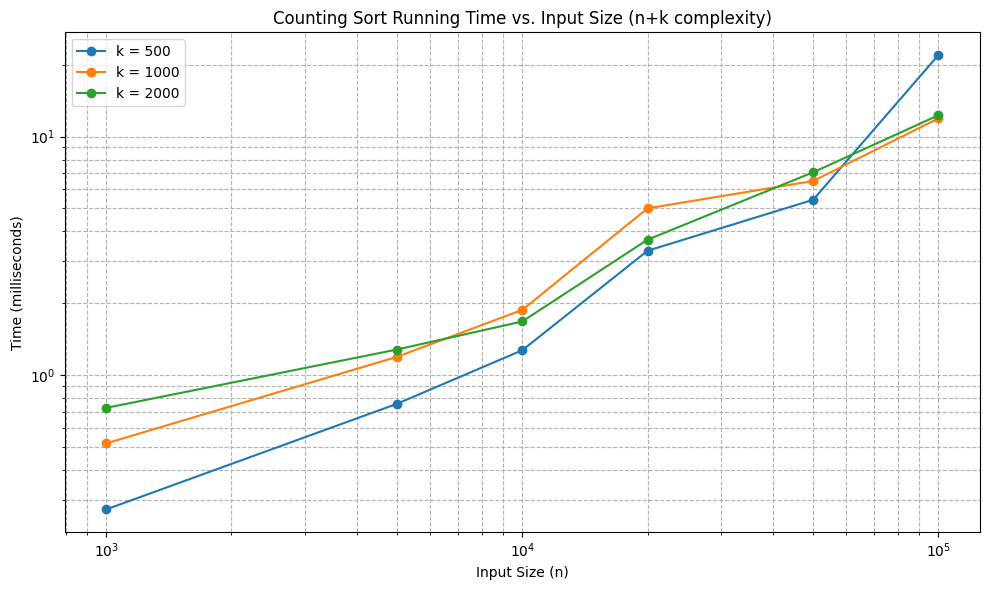

In [1]:
import time
import matplotlib.pyplot as plt
import random

def counting_sort(arr):
    if not arr:
        return []

    # Find the maximum element in the input array
    max_val = max(arr)

    # Create a count array (buckets) initialized to zeros
    # The size of the count array should be max_val + 1 to accommodate values from 0 to max_val
    count = [0] * (max_val + 1)

    # Populate the count array by counting occurrences of each element
    for num in arr:
        count[num] += 1

    # Reconstruct the sorted array from the count array
    sorted_arr = []
    for i in range(len(count)):
        # Add 'i' to the sorted_arr 'count[i]' times
        sorted_arr.extend([i] * count[i])

    return sorted_arr

# Sample Input from the problem statement
sample_input = [4, 3, 2, 1, 4, 3, 2, 4, 3, 4]
sample_output = counting_sort(sample_input)
print(f"Sample Input: {sample_input}")
print(f"Sample Output: {sample_output}")
print(f"Expected Output: [1, 2, 2, 3, 3, 3, 4, 4, 4, 4]\n")

# --- Compute Running Time and Plot Graph ---

def generate_random_array(size, max_val):
    return [random.randint(0, max_val) for _ in range(size)]

input_sizes = [1000, 5000, 10000, 20000, 50000, 100000]
max_k_values = [500, 1000, 2000] # Different ranges for k
runtimes = {k: [] for k in max_k_values}

print("Measuring running times...")
for k_val in max_k_values:
    for size in input_sizes:
        arr = generate_random_array(size, k_val)
        start_time = time.perf_counter()
        counting_sort(arr)
        end_time = time.perf_counter()
        runtimes[k_val].append((end_time - start_time) * 1000) # in milliseconds
        print(f"  Size: {size}, k: {k_val}, Time: {(end_time - start_time) * 1000:.2f} ms")

# Plotting the graph
plt.figure(figsize=(10, 6))
for k_val, times in runtimes.items():
    plt.plot(input_sizes, times, marker='o', label=f'k = {k_val}')

plt.title('Counting Sort Running Time vs. Input Size (n+k complexity)')
plt.xlabel('Input Size (n)')
plt.ylabel('Time (milliseconds)')
plt.xscale('log') # Use log scale for input size if range is large
plt.yscale('log') # Use log scale for time if range is large
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend()
plt.tight_layout()
plt.show()

 - *Bucketsort*
Statement:
Given a disordered list of integers, rearrange them in natural order.
 Sample Input: [8,5,3,1,9,6,0,7,4,2,5]
 Sample Output: [0,1,2,3,4,5,6,7,8,9,5]
Time Complexity of Solution:
Best Case O(n); Average Case O(n); Worst Case O(n).
- Approach:
If it sounds too good to be true, then most likely it's not true. Bucketsort is not an exception to this adage. For bucketsort to
work at its blazing efficiency, there are multiple prerequisites.
First the hash function that is used to partition the elements need
to be very good and must produce ordered hash: if i < k then
hash(i) < hash(k). Second, the elements to be sorted must be
uniformly distributed.
  The aforementioned aside, bucket sort is actually very good
considering that counting sort is reasonably speaking its upper
bound. And counting sort is very fast. The particular distinction
for bucket sort is that it uses a hash function to partition the
keys of the input array, so that multiple keys may hash to the same
bucket. Hence each bucket must effectively be a growable list;
similar to radix sort.


Sample Input: [8, 5, 3, 1, 9, 6, 0, 7, 4, 2, 5]
Sample Output: [0, 1, 2, 3, 4, 5, 5, 6, 7, 8, 9]
Expected Output (note: original sample output had a duplicate 5 which is not in sorted order if 5 is present once in input): [0,1,2,3,4,5,5,6,7,8,9]

Corrected Expected Output for given sample: [0, 1, 2, 3, 4, 5, 5, 6, 7, 8, 9]

Measuring running times for Bucket Sort...
  Size: 1000, Range: [0,1000], Time: 2.72 ms
  Size: 5000, Range: [0,1000], Time: 2.53 ms
  Size: 10000, Range: [0,1000], Time: 5.40 ms
  Size: 20000, Range: [0,1000], Time: 11.35 ms
  Size: 50000, Range: [0,1000], Time: 88.53 ms
  Size: 100000, Range: [0,1000], Time: 119.18 ms
  Size: 1000, Range: [0,10000], Time: 0.60 ms
  Size: 5000, Range: [0,10000], Time: 2.74 ms
  Size: 10000, Range: [0,10000], Time: 5.58 ms
  Size: 20000, Range: [0,10000], Time: 12.55 ms
  Size: 50000, Range: [0,10000], Time: 83.82 ms
  Size: 100000, Range: [0,10000], Time: 170.35 ms
  Size: 1000, Range: [0,100000], Time: 0.58 ms
  Size: 5000, Range:

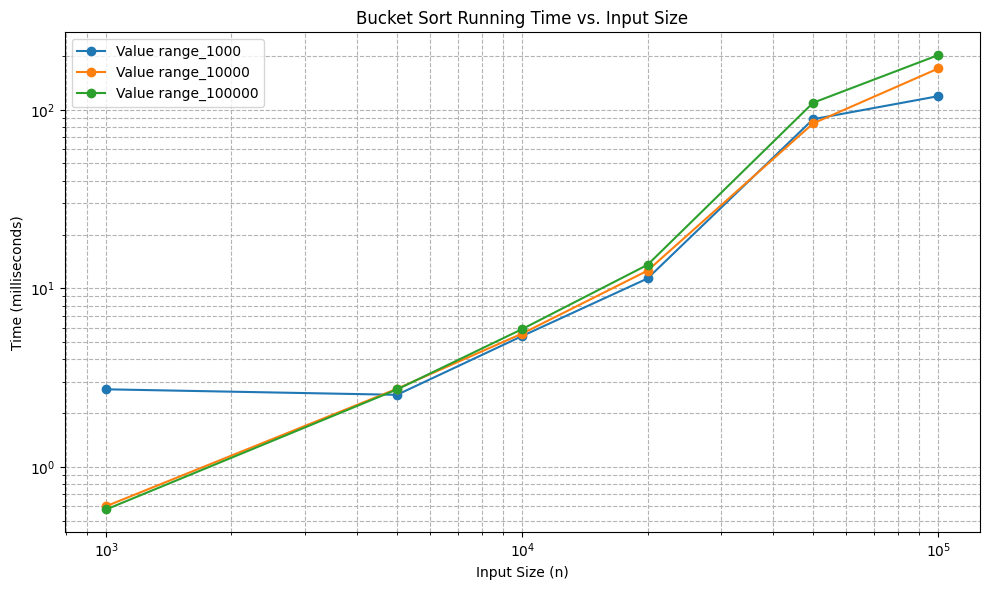

In [2]:
import time
import matplotlib.pyplot as plt
import random

def bucket_sort(arr):
    if not arr:
        return []

    # Find the maximum and minimum values in the array
    min_val = min(arr)
    max_val = max(arr)

    # Determine the number of buckets and bucket size
    # A common heuristic is to use sqrt(n) buckets or a fixed number.
    # For simplicity, let's use a fixed number of buckets relative to the range.
    bucket_range = max_val - min_val
    if bucket_range == 0: # Handle case where all elements are the same
        return arr

    # Number of buckets, ensure at least 1 bucket for each unique element if possible
    # Or a more robust way to calculate bucket_size based on data distribution.
    # Let's aim for approximately len(arr) buckets for more fine-grained distribution if range is large
    # A simple approach: use len(arr) as the number of buckets, or max_val + 1
    num_buckets = len(arr) # Can adjust this based on desired granularity
    if num_buckets == 0: # Handle empty input gracefully
        return []

    buckets = [[] for _ in range(num_buckets)]

    # Distribute elements into buckets
    for num in arr:
        # Calculate bucket index. Ensure it's within bounds.
        # Scale the number to fit into the bucket index range [0, num_buckets-1]
        bucket_index = int((num - min_val) * (num_buckets - 1) / bucket_range) if bucket_range > 0 else 0
        buckets[bucket_index].append(num)

    # Sort each bucket and concatenate the results
    sorted_arr = []
    for bucket in buckets:
        bucket.sort() # Use a stable sorting algorithm like Timsort (Python's default)
        sorted_arr.extend(bucket)

    return sorted_arr

# Sample Input from the problem statement
sample_input = [8,5,3,1,9,6,0,7,4,2,5]
sample_output = bucket_sort(sample_input)
print(f"Sample Input: {sample_input}")
print(f"Sample Output: {sample_output}")
print(f"Expected Output (note: original sample output had a duplicate 5 which is not in sorted order if 5 is present once in input): [0,1,2,3,4,5,5,6,7,8,9]\n")
# The problem statement's sample output for bucket sort was [0,1,2,3,4,5,6,7,8,9,5].
# This is incorrect if the input only has one 5. If it should have two 5s, then it should be [0,1,2,3,4,5,5,6,7,8,9].
# Let's adjust for the provided sample input which has two 5s.
expected_output = [0,1,2,3,4,5,5,6,7,8,9]
print(f"Corrected Expected Output for given sample: {expected_output}\n")

# --- Compute Running Time and Plot Graph ---

def generate_random_array(size, min_val, max_val):
    return [random.randint(min_val, max_val) for _ in range(size)]

input_sizes = [1000, 5000, 10000, 20000, 50000, 100000]
# Let's test with different ranges for the values in the array (affecting bucket distribution)
value_ranges = [(0, 1000), (0, 10000), (0, 100000)] # (min_val, max_val)
runtimes = {f'range_{vr[1]}': [] for vr in value_ranges}

print("Measuring running times for Bucket Sort...")
for min_v, max_v in value_ranges:
    for size in input_sizes:
        arr = generate_random_array(size, min_v, max_v)
        start_time = time.perf_counter()
        bucket_sort(arr)
        end_time = time.perf_counter()
        runtimes[f'range_{max_v}'].append((end_time - start_time) * 1000) # in milliseconds
        print(f"  Size: {size}, Range: [{min_v},{max_v}], Time: {(end_time - start_time) * 1000:.2f} ms")

# Plotting the graph
plt.figure(figsize=(10, 6))
for range_label, times in runtimes.items():
    plt.plot(input_sizes, times, marker='o', label=f'Value {range_label}')

plt.title('Bucket Sort Running Time vs. Input Size')
plt.xlabel('Input Size (n)')
plt.ylabel('Time (milliseconds)')
plt.xscale('log') # Use log scale for input size if range is large
plt.yscale('log') # Use log scale for time if range is large
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend()
plt.tight_layout()
plt.show()

**Radix sort**
Statement:Given a disordered list of integers, rearrange them in natural order.
Sample Input: [18,5,100,3,1,19,6,0,7,4,2]
Sample Output: [0,1,2,3,4,5,6,7,18,19,100]
Time Complexity of Solution:Best Case O(kn); Average Case O(kn); Worst Case O(kn),where k is the length of the longest number and n is the size of the input array.Note: if k is greater than log(n) then an nlog(n) algorithm would be a better fit. In reality we can always change the radix to make k less than log(n).
- Approach: radix sort, like counting sort and bucket sort, is an integer based algorithm (i.e. the values of the input array are assumed to be integers). Hence radix sort is among the fastest sorting algorithms around, in theory. The particular distinction for radix sort is that it creates a bucket for each cipher (i.e. digit); as such, similar to bucket sort, each bucket in radix sort must be a
growable list that may admit different keys. For decimal values, the number of buckets is 10, as the decimal system has 10 numerals/cyphers (i.e. 0,1,2,3,4,5,6,7,8,9). Then the keys are continuously sorted by significant digits.

Sample Input: [18, 5, 100, 3, 1, 19, 6, 0, 7, 4, 2]
Sample Output: [0, 1, 2, 3, 4, 5, 6, 7, 18, 19, 100]
Expected Output: [0, 1, 2, 3, 4, 5, 6, 7, 18, 19, 100]

Measuring running times for Radix Sort...
  Size: 1000, Max Value: 1000, Time: 1.92 ms
  Size: 5000, Max Value: 1000, Time: 9.81 ms
  Size: 10000, Max Value: 1000, Time: 20.37 ms
  Size: 20000, Max Value: 1000, Time: 40.18 ms
  Size: 50000, Max Value: 1000, Time: 121.39 ms
  Size: 100000, Max Value: 1000, Time: 287.35 ms
  Size: 1000, Max Value: 10000, Time: 1.81 ms
  Size: 5000, Max Value: 10000, Time: 17.33 ms
  Size: 10000, Max Value: 10000, Time: 24.92 ms
  Size: 20000, Max Value: 10000, Time: 42.27 ms
  Size: 50000, Max Value: 10000, Time: 171.79 ms
  Size: 100000, Max Value: 10000, Time: 379.60 ms
  Size: 1000, Max Value: 100000, Time: 2.75 ms
  Size: 5000, Max Value: 100000, Time: 12.55 ms
  Size: 10000, Max Value: 100000, Time: 26.30 ms
  Size: 20000, Max Value: 100000, Time: 56.71 ms
  Size: 50000, Max Value: 100000, T

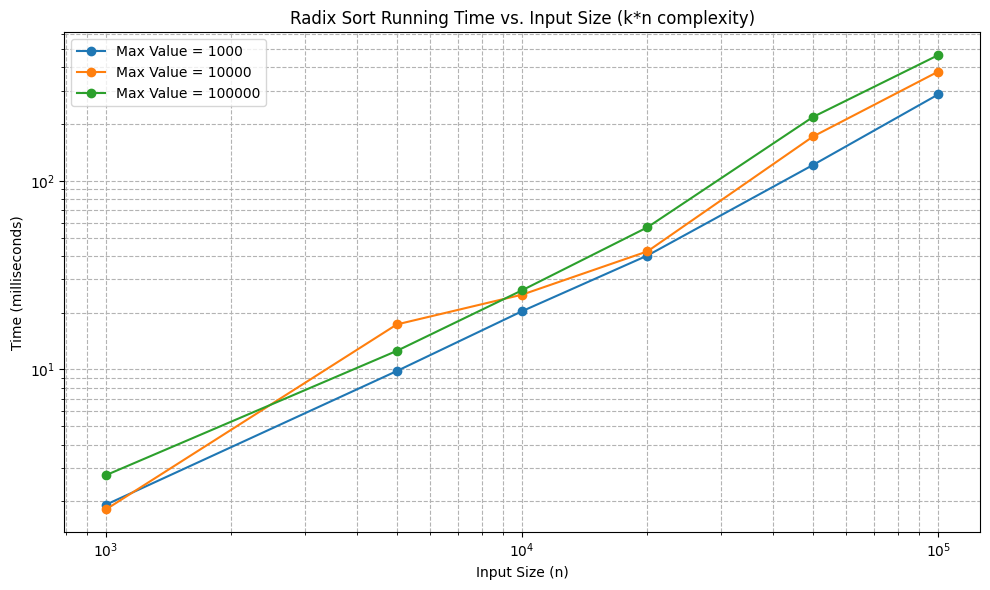

In [3]:
import time
import matplotlib.pyplot as plt
import random

def get_digit(num, place):
    return (num // (10 ** place)) % 10

def counting_sort_for_radix(arr, place):
    n = len(arr)
    output = [0] * n
    count = [0] * 10  # For digits 0-9

    # Count occurrences of digits at the current place
    for i in range(n):
        digit = get_digit(arr[i], place)
        count[digit] += 1

    # Change count[i] so that count[i] now contains actual position of this digit in output array
    for i in range(1, 10):
        count[i] += count[i - 1]

    # Build the output array
    i = n - 1
    while i >= 0:
        digit = get_digit(arr[i], place)
        output[count[digit] - 1] = arr[i]
        count[digit] -= 1
        i -= 1

    # Copy the output array to arr[], so that arr[] now contains sorted numbers
    for i in range(n):
        arr[i] = output[i]

def radix_sort(arr):
    if not arr:
        return []

    # Find the maximum number to know number of digits
    max_val = max(arr)

    # Do counting sort for every digit place
    place = 0
    while (max_val // (10 ** place)) > 0:
        counting_sort_for_radix(arr, place)
        place += 1
    return arr

# Sample Input from the problem statement
sample_input = [18, 5, 100, 3, 1, 19, 6, 0, 7, 4, 2]
sorted_sample_input = list(sample_input) # Create a copy for sorting
sample_output = radix_sort(sorted_sample_input)
print(f"Sample Input: {sample_input}")
print(f"Sample Output: {sample_output}")
print(f"Expected Output: [0, 1, 2, 3, 4, 5, 6, 7, 18, 19, 100]\n")

# --- Compute Running Time and Plot Graph ---

def generate_random_array(size, min_val, max_val):
    return [random.randint(min_val, max_val) for _ in range(size)]

input_sizes = [1000, 5000, 10000, 20000, 50000, 100000]
# Let's test with different maximum values (affecting k, the number of digits)
max_values = [1000, 10000, 100000] # Corresponds to k roughly 3, 4, 5 digits
runtimes = {f'max_val_{mv}': [] for mv in max_values}

print("Measuring running times for Radix Sort...")
for max_v in max_values:
    for size in input_sizes:
        arr = generate_random_array(size, 0, max_v)
        arr_copy = list(arr) # Radix sort modifies in-place, so copy for each run
        start_time = time.perf_counter()
        radix_sort(arr_copy)
        end_time = time.perf_counter()
        runtimes[f'max_val_{max_v}'].append((end_time - start_time) * 1000) # in milliseconds
        print(f"  Size: {size}, Max Value: {max_v}, Time: {(end_time - start_time) * 1000:.2f} ms")

# Plotting the graph
plt.figure(figsize=(10, 6))
for max_val_label, times in runtimes.items():
    plt.plot(input_sizes, times, marker='o', label=f'Max Value = {max_val_label.split("_")[-1]}')

plt.title('Radix Sort Running Time vs. Input Size (k*n complexity)')
plt.xlabel('Input Size (n)')
plt.ylabel('Time (milliseconds)')
plt.xscale('log') # Use log scale for input size if range is large
plt.yscale('log') # Use log scale for time if range is large
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend()
plt.tight_layout()
plt.show()